## Carregando os dados com a auxilio do pandas

In [5]:
# [1] Primeiro deve rodar essa parte de codigo para o arquivo data.csv seja lido
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_csv("../data/raw/data.csv")

# Visualizar primeiras linhas
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Esse grafico mostra a quantidade total de cancer maligno e de cancer benigno em relação ao total de pessoas.

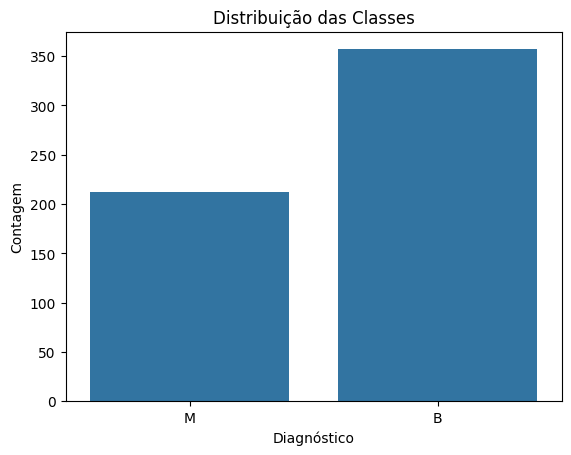

In [6]:
# [2] Gráfico em barras para mostrar a distribuição das classes (Maligno vs Benigno)
sns.countplot(x="diagnosis", data=df)
plt.title("Distribuição das Classes")
plt.xlabel("Diagnóstico")
plt.ylabel("Contagem")
plt.show()

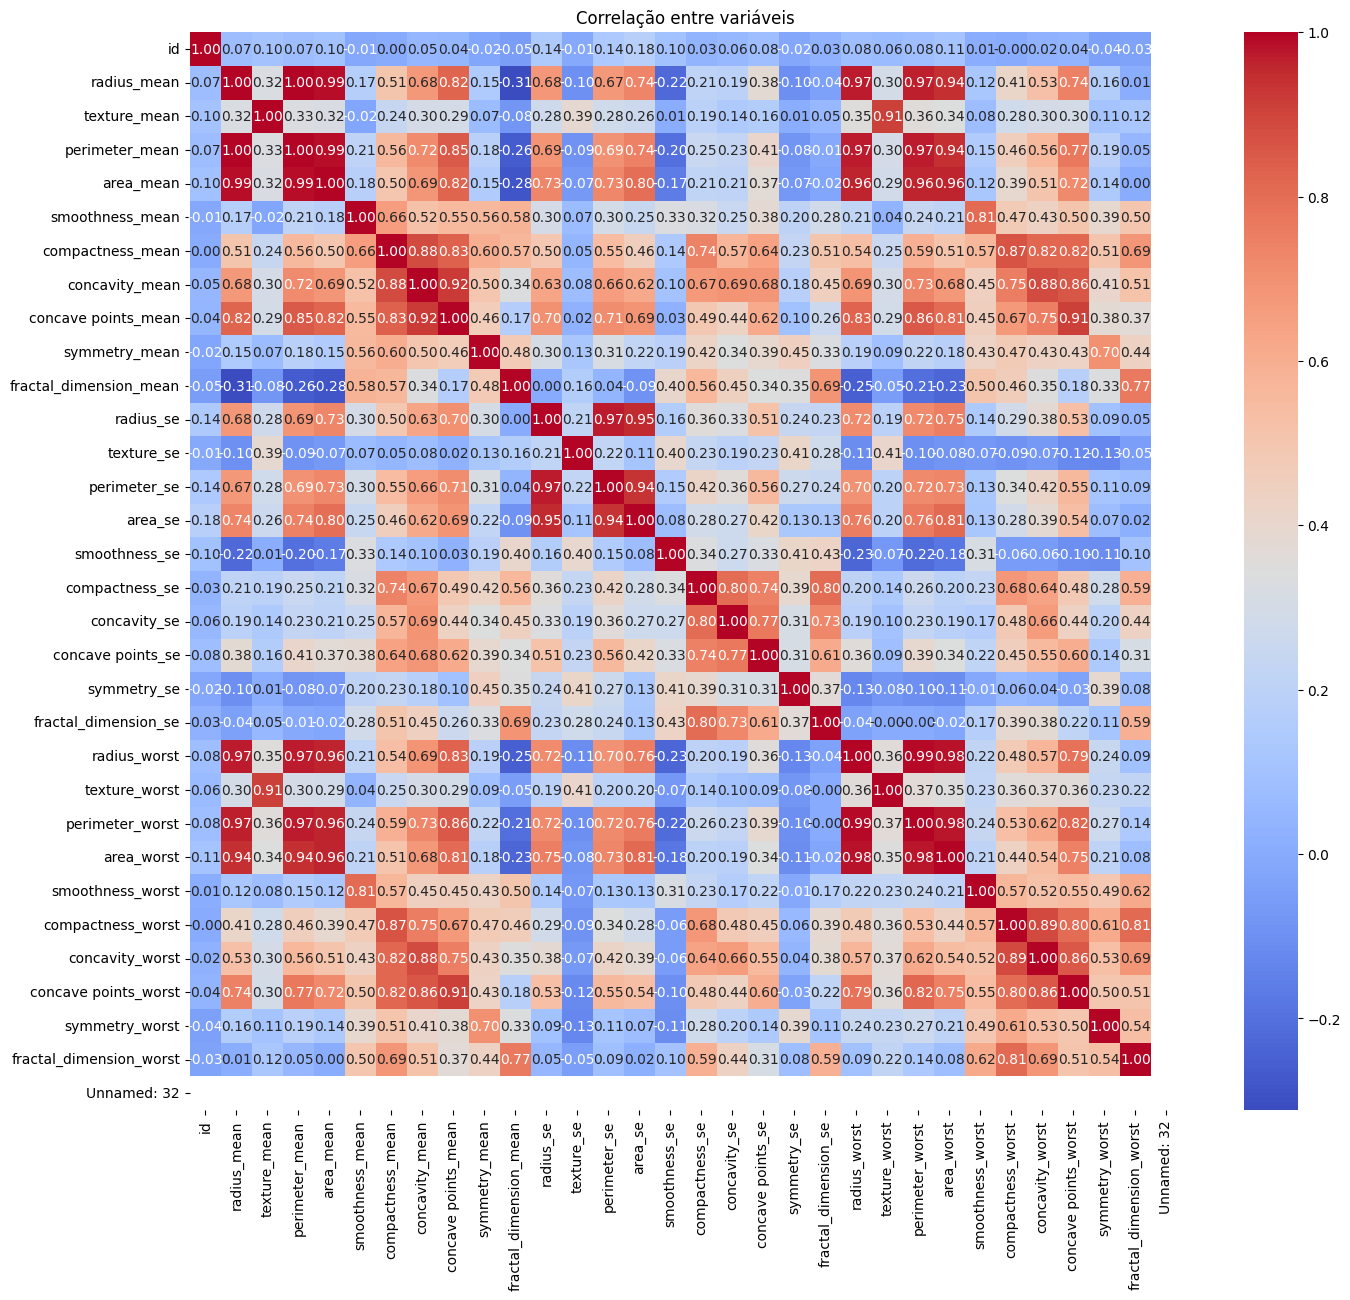

In [7]:
# [3] Heatmap de correlação entre as variáveis numéricas
import numpy as np

plt.figure(figsize=(16, 14))

corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Correlação entre variáveis")
plt.show()

In [ ]:
# [4] Mostra quais variáveis mais influenciam o diagnóstico.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

corr_target = df.corr()['diagnosis'].sort_values(ascending=False)

print(corr_target)

In [ ]:
# [5] Heatmap de correlação entre as variáveis numéricas mais importantes
top_features = corr_target.abs().sort_values(ascending=False).head(10).index

corr_top = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top correlações")
plt.show()

In [ ]:
# [6] Pairplot (relações visuais entre variáveis)
sns.pairplot(df[top_features], hue='diagnosis')
plt.show()

In [ ]:
# [7] Distribuição por classe, mostra como as variáveis se distribuem para cada classe (Maligno vs Benigno)
for col in top_features[:5]:
    plt.figure()
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

In [ ]:
# [8] Boxplot por classe, mostra a distribuição das variáveis para cada classe (Maligno vs Benigno)
for col in top_features[:5]:
    plt.figure()
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

In [ ]:
# [9] Detectar multicolinearidade entre as variáveis numéricas, mostrando quais variáveis estão altamente correlacionadas entre si.
import numpy as np
corr = df.select_dtypes(include=[np.number]).corr()
high_corr = corr.abs() > 0.9

print(high_corr.sum().sort_values(ascending=False))

In [ ]:
# [10] Heatmap triangular para mostrar apenas a parte superior da matriz de correlação, evitando redundância.
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação (triangular)")
plt.show()

In [ ]:
# Ranking das variáveis mais importantes para o diagnóstico, mostrando as 10 mais influentes.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

corr_target = df.corr()['diagnosis'].abs().sort_values(ascending=False)

print(corr_target[1:10])

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64
